# Step 3: MSM construction and validation

In [1]:
data_folder = "./data/"

import numpy as np
import matplotlib.pyplot as plt

import pandas as pd
from sklearn.decomposition import PCA
from deeptime.decomposition import TICA
import networkx as nx # graph visualization of MSM microstates and macrostates model
# Compute the transition COUNTS matrix C from trajectory
from deeptime.markov import TransitionCountEstimator
# Estimate the transition matrix T from C
from deeptime.markov.msm import MaximumLikelihoodMSM
from tqdm.notebook import tqdm  # progress bar (optional)
from deeptime.clustering import KMeans

In [2]:
def plot_free_energy_projection(dimred_traj, component_x, component_y, ax = None, vmin = None, vmax = None, axlabel = "PC", axtitle = None):

    if ax == None:
        fig, ax__ = plt.subplots(1, 1, figsize=(5, 4))
    else:
        ax__ = ax

    # Scatter plot
    ax__.scatter(
        dimred_traj[:, component_x],
        dimred_traj[:, component_y],
        s=0.01,
        alpha=0.3
    )

    #ax__.xaxis.tick_top()
    #ax__.xaxis.set_label_position("top")
    ax__.set_xlabel(f"{axlabel}{component_x}", labelpad=1)
    ax__.set_ylabel(f"{axlabel}{component_y}")


    # 2D histogram (Free energy)
    H, xedges, yedges = np.histogram2d(
        dimred_traj[:, component_x],
        dimred_traj[:, component_y],
        bins=100,
        density=True
    )
    mask = H > 0
    F = np.full_like(H, np.nan)
    F[mask] = -np.log(H[mask])
    F -= np.nanmin(F)

    im = ax__.imshow(
        F.T,
        origin="lower",
        extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
        aspect="auto",
        vmin=vmin,
        vmax=vmax
    )
    #if colorbarlabel is not None:
    #    plt.colorbar(im, ax=ax__, label=r"$F/k_B T$")
    #else:
    #    plt.colorbar(im, ax=ax__)
    ax__.set_xlabel(f"{axlabel}{component_x}")
    ax__.set_ylabel(f"{axlabel}{component_y}")
    if axtitle is not None:
        ax__.set_title(f"{axtitle}")

    return ax__, im

---
#### Loading raw data

In [3]:
# set 1: distances
distances = np.loadtxt(data_folder + "hp35.mindists2", delimiter = " ", dtype = float)
print("Data shape", distances.shape) # [nm] nanometers
print("Data size (MB)", distances.nbytes / (10**6))

# set 2: dihedrals
dihedrals = np.loadtxt(data_folder + "hp35.dihs.shifted", delimiter = " ", dtype = float)
print(dihedrals.shape) # [radians] 


total_time_micros = 300
time_step_micros =  total_time_micros / distances.shape[0]
print("Time step (microseconds)", time_step_micros) # 2x10^-4 microseconds
print("Time step (nanoseconds)", time_step_micros * 10**3) # 0.2 nanoseconds
print("Time step (picoseconds)", time_step_micros * 10**6) # 200 picoseconds


one_microsecond_in_frames = int(1 / time_step_micros)
print("One microsecond in frames", one_microsecond_in_frames) # 5000 frames

Data shape (1526041, 42)
Data size (MB) 512.749776
(1526041, 66)
Time step (microseconds) 0.00019658711659778472
Time step (nanoseconds) 0.19658711659778472
Time step (picoseconds) 196.58711659778473
One microsecond in frames 5086


---
### Performing dim. reduction with the previously selected hyperparams 

In [4]:
tica_lag = 1000 # lag time for TICA in frames, 1000 frames = 200 nanoseconds
tica_dim_distances = 5
tica_dim_dihedrals = 7
pca_dim_distances = 5
pca_dim_dihedrals = 7

# set 1: distances
tica_model = TICA(lagtime = tica_lag, dim = tica_dim_distances).fit(distances)
tica_distances = tica_model.transform(distances)
pca_distances = PCA(n_components = pca_dim_distances).fit_transform(distances)

# set 2: dihedrals
tica_model = TICA(lagtime = tica_lag, dim = tica_dim_dihedrals).fit(dihedrals)
tica_dihedrals = tica_model.transform(dihedrals)
pca_dihedrals = PCA(n_components = pca_dim_dihedrals).fit_transform(dihedrals)

# save the TICA and PCA features for later use
np.save(f"intermediate_outputs/dimred/tica_dihedrals.npy", tica_dihedrals)
np.save(f"intermediate_outputs/dimred/pca_dihedrals.npy", pca_dihedrals)
np.save(f"intermediate_outputs/dimred/tica_distances.npy", tica_distances)
np.save(f"intermediate_outputs/dimred/pca_distances.npy", pca_distances)

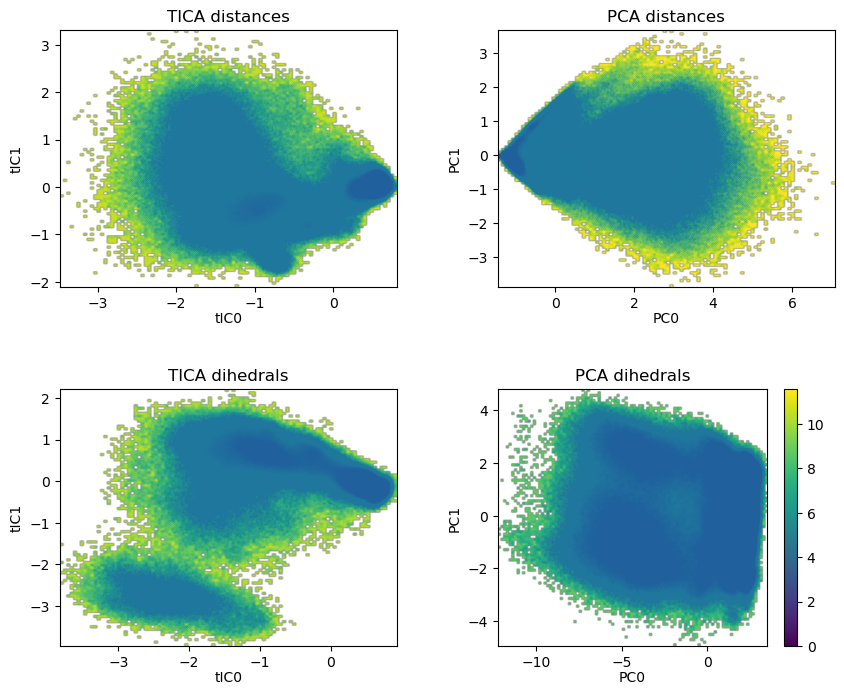

In [5]:
# First pass: compute all FESs
Fs = []
trajectories = [tica_distances, pca_distances, tica_dihedrals, pca_dihedrals]
trajectories_labels = ["tica_distances", "pca_distances", "tica_dihedrals", "pca_dihedrals"]
component_x = 0
component_y = 1
for traj in trajectories:
    H, xedges, yedges = np.histogram2d(
        traj[:, component_x],
        traj[:, component_y],
        bins=100,
        density=True
    )
    mask = H > 0
    F = np.full_like(H, np.nan)
    F[mask] = -np.log(H[mask])
    F -= np.nanmin(F)
    Fs.append(F)

# Global limits
vmin = 0
vmax = np.nanmax([np.nanmax(F) for F in Fs])



fig, axes = plt.subplots(2, 2, figsize=(10, 8))
plot_free_energy_projection(tica_distances, 0, 1, ax = axes[0, 0], vmin = vmin, vmax=vmax, axlabel = "tIC", axtitle = "TICA distances")
plot_free_energy_projection(pca_distances, 0, 1, ax = axes[0, 1], vmin = vmin, vmax=vmax, axlabel = "PC", axtitle = "PCA distances")
plot_free_energy_projection(tica_dihedrals, 0, 1, ax = axes[1, 0], vmin = vmin, vmax=vmax, axlabel = "tIC", axtitle = "TICA dihedrals")
ax, im = plot_free_energy_projection(pca_dihedrals, 0, 1, ax = axes[1, 1], vmin = vmin, vmax=vmax, axlabel = "PC", axtitle = "PCA dihedrals")
plt.colorbar(im, ax=ax)
plt.subplots_adjust(wspace=0.3, hspace=0.4)
plt.show()

---
### performing kmeans clustering + msm transition matrix estimation + implied timescales test

In [53]:
kcluster_list = [10000] #[100, 200, 500]



for n_clusters in kcluster_list:
    print(f"Running KMeans with {n_clusters} clusters...")
    kmeans = KMeans(
        n_clusters=n_clusters,
        init_strategy='kmeans++',
        max_iter=100,
        fixed_seed=13,
        n_jobs=8,
        progress=tqdm
    )
    #for i, traj in enumerate(trajectories):
    for i, traj in enumerate([tica_dihedrals]):
        #traj_name = trajectories_labels[i]
        traj_name = "tica_dihedrals"
        kmeans.fit(traj)
        discretized_trajectories = kmeans.transform(traj)
        model = kmeans.fetch_model() # fetches the latest model, containing all important information
        np.savez(f"intermediate_outputs/kmeans_plusplus/{n_clusters}clusters_{traj_name}", traj = discretized_trajectories, centers = model.cluster_centers)


Running KMeans with 10000 clusters...


  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

Text(0.5, 1.0, 'KMeans with uniform initialization inertia during training')

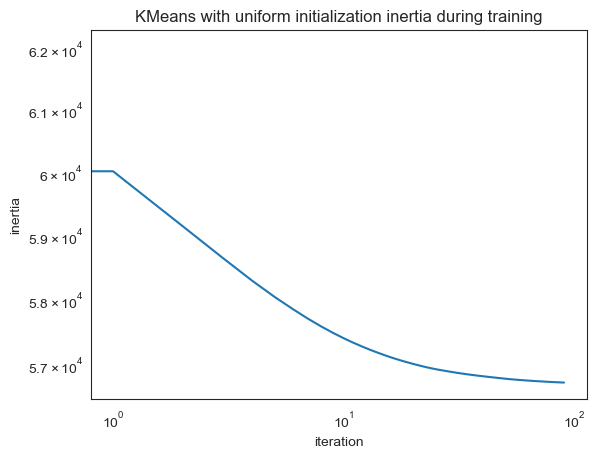

In [54]:
plt.loglog(model.inertias)
plt.xlabel("iteration")
plt.ylabel("inertia")
plt.title("KMeans with uniform initialization inertia during training")

---

In [58]:
#trajectories_labels = ["tica_distances", "pca_distances", "tica_dihedrals", "pca_dihedrals"]
trajectories_labels = ["tica_dihedrals"]
lagtimes = np.array([10, 20, 30, 40, 60, 100, 200, 300, 400, 500]) # lag times in frames (10 frames = 2 nanoseconds, 5000 frames = 1 microsecond)

df = pd.DataFrame(
    index=pd.MultiIndex.from_product(
        [trajectories_labels, kcluster_list, lagtimes],
        names=["Trajectory", "N_clusters", "Lag"]
    ),
    columns=[f"Timescale_{i}" for i in range(1, 11)],
    dtype=float
)

strongly_connected_sets = {}
weakly_connected_sets = {}

for n_clusters in [100, 200, 500]:
#for n_clusters in kcluster_list:
    for traj_name in trajectories_labels:

        data = np.load(f"intermediate_outputs/kmeans/{n_clusters}clusters_{traj_name}.npz")
        #data = np.load(f"intermediate_outputs/kmeans_plusplus/{n_clusters}clusters_{traj_name}.npz")
        dtraj = data["traj"]
        populated_clusters = np.unique(dtraj)

        for lag in lagtimes:
            tce = TransitionCountEstimator(
                lagtime=lag,
                count_mode="sliding-effective"
            )
            C = tce.fit(dtraj).fetch_model()

            msm = MaximumLikelihoodMSM(reversible = True).fit(C).fetch_model()
            its = msm.timescales(k=10)
            cols = [f"Timescale_{i}" for i in range(1, len(its) + 1)]
            df.loc[(traj_name, n_clusters, lag), cols] = its
            df.to_csv("intermediate_outputs/implied_timescales.csv", mode = "a", header = False)
            #df.to_csv("intermediate_outputs/implied_timescales_plusplus.csv", mode = "a", header = False)
            df.head()

        #print(f"Features: {traj_name}, clusters: {n_clusters}, lag: {lag}")
        #print("Weakly connected sets:", len(C.connected_sets(directed=False)))
        #print("Strongly connected sets:", len(C.connected_sets(directed=True)))
        #strongly_connected_sets[(traj_name, n_clusters, lag)] = C.connected_sets(directed=True)
        #weakly_connected_sets[(traj_name, n_clusters, lag)] = C.connected_sets(directed=False)

Skipping state set [12] due to error in estimation: Some row and corresponding column of the count matrix C have zero counts..
Skipping state set [12] due to error in estimation: Some row and corresponding column of the count matrix C have zero counts..
Skipping state set [12] due to error in estimation: Some row and corresponding column of the count matrix C have zero counts..
Skipping state set [12] due to error in estimation: Some row and corresponding column of the count matrix C have zero counts..
Skipping state set [12] due to error in estimation: Some row and corresponding column of the count matrix C have zero counts..
Skipping state set [12] due to error in estimation: Some row and corresponding column of the count matrix C have zero counts..
Skipping state set [12] due to error in estimation: Some row and corresponding column of the count matrix C have zero counts..
Skipping state set [12] due to error in estimation: Some row and corresponding column of the count matrix C hav

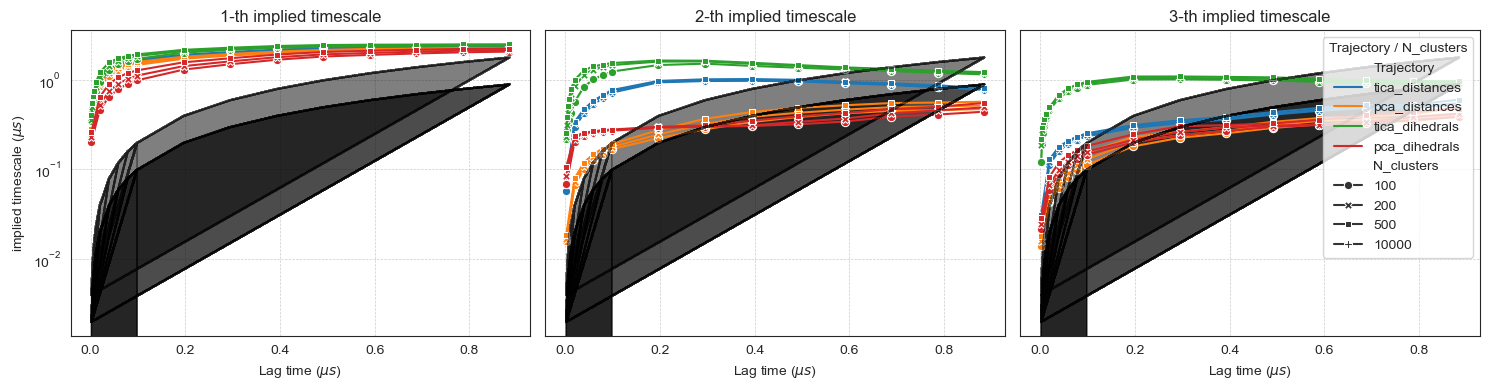

In [63]:
import seaborn as sns

df = pd.read_csv("intermediate_outputs/implied_timescales.csv", index_col=[0, 1, 2])
#df = pd.read_csv("intermediate_outputs/implied_timescales_plusplus.csv", index_col=[0, 1, 2])
df.index.names = ["Trajectory", "N_clusters", "Lag"]
df = df.reset_index()
sns.set_style("white")

df["Lag"] = df["Lag"].astype(float) * time_step_micros
for col in df.columns:
    if col.startswith("Timescale_"):
        df[col] = df[col].astype(float) * time_step_micros


n_timescales_to_plot = 3

fig, axs = plt.subplots(1, n_timescales_to_plot, figsize=(5*n_timescales_to_plot, 4), sharey=True, sharex=True)
#plt.figure(figsize=(8, 4))


for i in range(1, n_timescales_to_plot + 1):
    sns.lineplot(data=df, ax = axs[i-1], x="Lag", y=f"Timescale_{i}", hue="Trajectory", style="N_clusters", markers=True, dashes=False)
    axs[i-1].plot(df["Lag"], df["Lag"], color = "black", alpha = 0.7) 
    axs[i-1].fill_between(df["Lag"], 0,  df["Lag"], color = "black", alpha = 0.7) 
    axs[i-1].plot(df["Lag"], 2*df["Lag"], color = "black", alpha = 0.5) 
    axs[i-1].fill_between(df["Lag"], 0,  2*df["Lag"], color = "black", alpha = 0.5) 
    axs[i-1].set_xlabel("Lag time ($\mu s$)") 
    axs[i-1].set_ylabel(f"implied timescale ($\mu s$)")
    axs[i-1].set_title(f"{i}-th implied timescale")
    axs[i-1].set_yscale("log")
    #plt.legend(title="Trajectory / N_clusters")#, bbox_to_anchor=(1.05, 1), loc='upper left')
    axs[i-1].grid(axis = "both", linestyle = "--", linewidth = 0.5)
    if i != n_timescales_to_plot:
        axs[i-1].get_legend().remove()


axs[n_timescales_to_plot - 1].legend(title="Trajectory / N_clusters", loc = "upper right")
plt.tight_layout()
plt.show()

---
### Timescales test is not good enough - let's inspect the clusters

First implied timescale converges around $\sim 0.8\,\mu s$, which is too large. It is expected to converge at a lagtime that is *significatively* smaller than the timescale, otherwise the MSM cannot resolve the process well!

Probably need to change the clustering algorithm, or increase state space dimension.

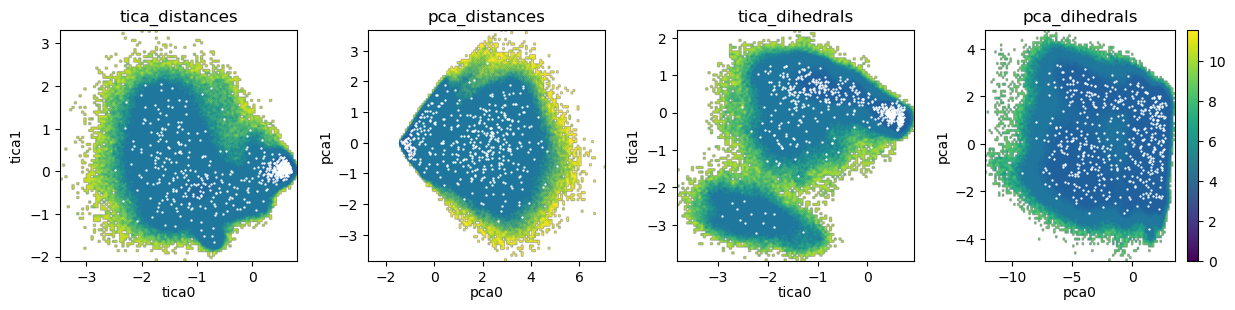

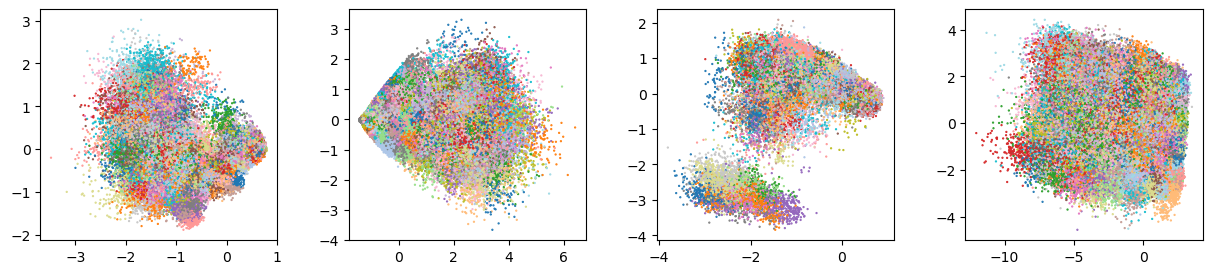

In [45]:
n_clu_for_plot = 500

feature_names = ["distances", "dihedrals"]
fig, axes = plt.subplots(1, 4, figsize=(15, 3))
axes = axes.flatten()
for i, (traj_name) in enumerate(trajectories_labels):
        data = np.load(f"intermediate_outputs/kmeans/{n_clu_for_plot}clusters_{traj_name}.npz")
        centers = data["centers"]
        method = traj_name.split("_")[0]
        dtraj = np.load(f"intermediate_outputs/dimred/{traj_name}.npy")
        if i == len(trajectories_labels) - 1:
                axes[-1], im = plot_free_energy_projection(dtraj, 0, 1, ax = axes[-1], vmin = vmin, vmax=vmax, axlabel = f"{method}", axtitle = f"{traj_name}")
                plt.colorbar(im, ax=axes[-1])
        else:
                plot_free_energy_projection(dtraj, 0, 1, ax = axes[i], vmin = vmin, vmax=vmax, axlabel = f"{method}", axtitle = f"{traj_name}")
        axes[i].scatter(centers[:, 0], centers[:, 1], s=0.4, alpha=1, color = "white",  label = traj_name)

plt.subplots_adjust(wspace=0.3, hspace=0.4)
plt.show()


# Plot assignments

fig, axes = plt.subplots(1, 4, figsize=(15, 3))
axes = axes.flatten()
for i, (traj_name) in enumerate(trajectories_labels):
        data = np.load(f"intermediate_outputs/kmeans/{n_clu_for_plot}clusters_{traj_name}.npz")
        assignments = data["traj"]
        method = traj_name.split("_")[0]
        dtraj = np.load(f"intermediate_outputs/dimred/{traj_name}.npy")
        axes[i].scatter(dtraj[:, 0][::10], dtraj[:, 1][::10], c = assignments[::10], cmap = "tab20", s=0.4, alpha=1,  label = traj_name)

plt.subplots_adjust(wspace=0.3, hspace=0.4)
plt.show()


This clustering was done with a **uniform** initialization.

It becomes evident that almost all of the 100 cluster centers are placed in the area of the highly populated component. This can be a disadvantage when building Markov state models, as here one would be interested in the transition between states and this clustering only resolves the highly populated state.


Although computationally more costly than initializing the centers uniformly, **kmeans++** initialization leads to an initial distribution under which the centers yield a better coverage of the state space.
The idea is to choose the initial cluster centers subsequently such that each chosen cluster center is not near any of the previously chosen ones. Therefore the uniform distribution is replaced by a weighted distribution that uses the squared distances to the set of already chosen centers.


Alternatively, regular space clustering or MPP can be used.

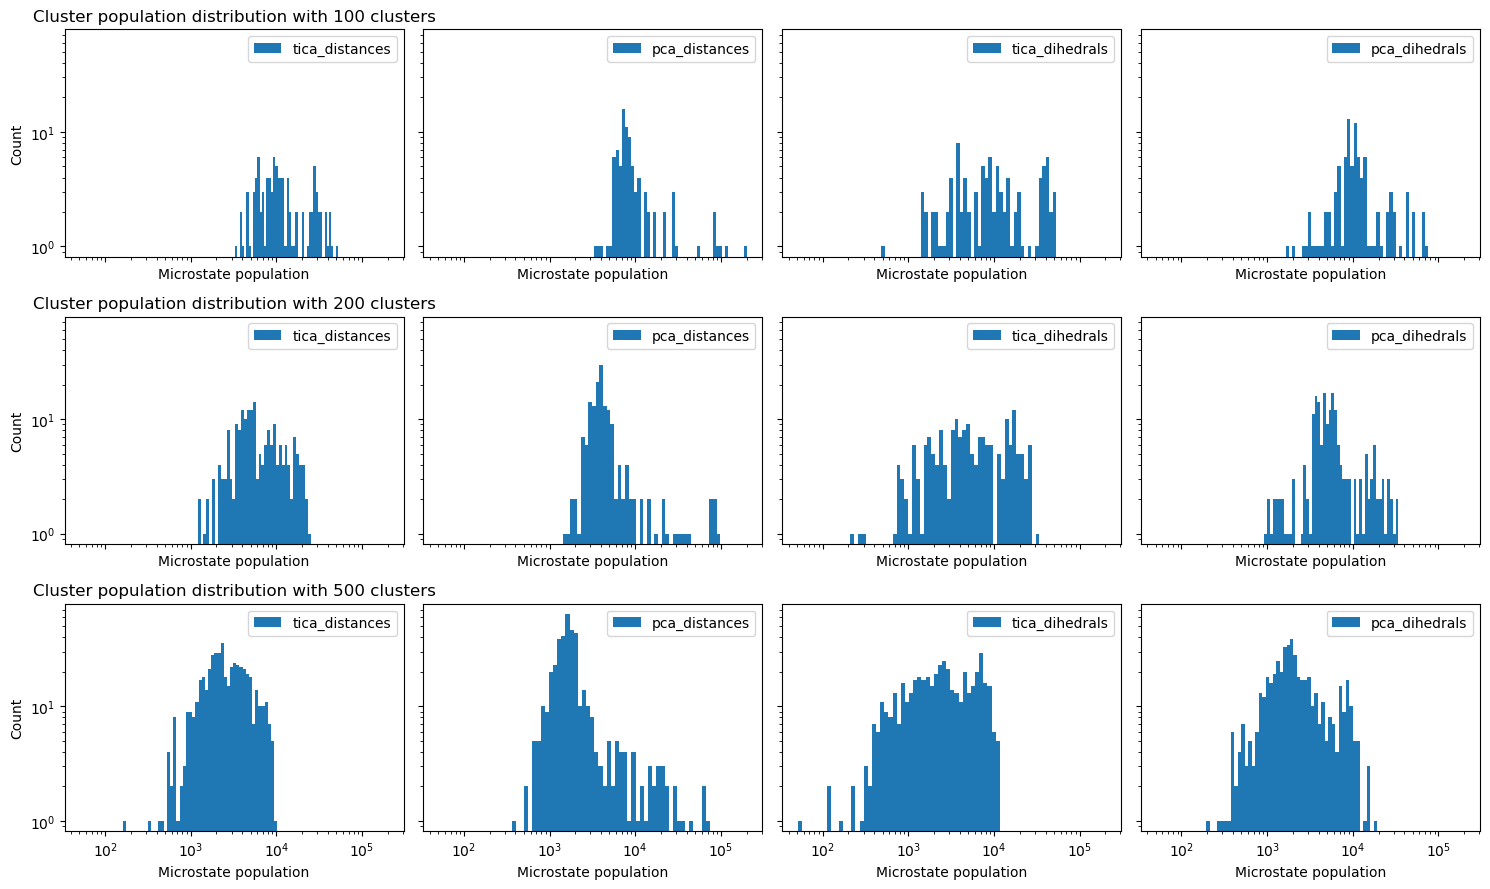

In [40]:
# check cluster populations
fig, axes = plt.subplots(
    len(kcluster_list),
    len(trajectories_labels),
    figsize=(15, 3 * len(kcluster_list)),
    sharex=True,
    sharey=True,
)


for row, n_clusters in enumerate(kcluster_list):
    for col, traj_name in enumerate(trajectories_labels):
        ax = axes[row, col]
        data = np.load(f"intermediate_outputs/kmeans/{n_clusters}clusters_{traj_name}.npz")
        assignments = data["traj"]
        unique, counts = np.unique(assignments, return_counts=True)
        bins = np.logspace(np.log10(counts.min()),
                np.log10(counts.max()),
                50)

        ax.hist(counts, bins=bins, label=traj_name)
        #axs[i].hist(counts, bins=50, label = traj_name)
        ax.set_xscale("log")
        ax.legend()
        ax.set_yscale("log")
        ax.set_xlabel("Microstate population")
        if col == 0:
                ax.set_ylabel("Count")
                ax.set_title(f"Cluster population distribution with {n_clusters} clusters")

plt.tight_layout()
plt.show()

Lets have a try at Regular space clustering instead - on tica dihedrals only for the moment

/var/folders/vk/kftm8379123bsmwrdp8l0xr00000gn/T/ipykernel_3510/3980228400.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


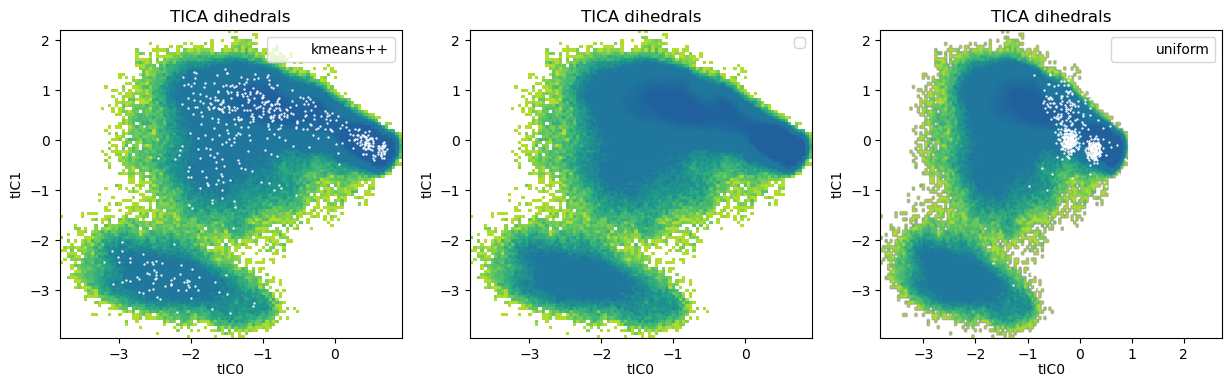

In [44]:
from deeptime.clustering import RegularSpace

nclu = 500


#reg_space_clusterer = RegularSpace(
#    dmin=1,  # minimum distance between cluster centers
#    max_centers=nclu,  # maximum number of cluster centers
#    n_jobs=8
#    #max_iter=1,
#)

plusplus_clusterer = KMeans(
    n_clusters=nclu,
    init_strategy='kmeans++',
    max_iter=1,
    fixed_seed=13,
    n_jobs=8)


uniform_clusterer = KMeans(
    n_clusters=nclu,
    init_strategy='uniform',
    max_iter=1,
    fixed_seed=13,
    n_jobs=8)

trajectory = tica_dihedrals


plus_plus_centers = plusplus_clusterer.fit(trajectory).fetch_model().cluster_centers
regspace_centers = reg_space_clusterer.fit(trajectory).fetch_model().cluster_centers
uniform_centers = uniform_clusterer.fit(trajectory).fetch_model().cluster_centers



# plot the centers on top of the free energy landscape
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax in axes:
    plot_free_energy_projection(trajectory, 0, 1, ax = ax, vmin = vmin, vmax=vmax, axlabel = "tIC", axtitle = "TICA dihedrals")
axes[0].scatter(plus_plus_centers[:, 0], plus_plus_centers[:, 1], s=0.4, alpha=1, color = "white", label = "kmeans++")
#axes[1].scatter(regspace_centers[:, 1], regspace_centers[:, 1], s=0.4, alpha=1, color = "white", label = "regular space")
axes[2].scatter(uniform_centers[:, 2], uniform_centers[:, 1], s=0.4, alpha=1, color = "white", label = "uniform")
for ax in axes:
    ax.legend()
plt.show()

---
### Reload the trajectory, already discretized into MSM-microstates

In [4]:
kmeans_results = np.load("intermediate_outputs/kmeans_results.npz")

traj = kmeans_results['traj']
centers = kmeans_results['centers']

### Given a lag time $\tau$, count the transitions


$$
    C_{\tau}(i, j) = \text{n. of transitions}\quad s(t+\tau)=i \leftarrow s(t)=j
$$

Parameters to choose:
- lag time, $\tau \in \mathbb{N}$ at which to compute the counts matrix 
- the counting mode: "sample", "sliding", "sliding-effective", "effective". See [deeptime documentation](https://deeptime-ml.github.io/latest/notebooks/transition-counting.html).


In [8]:
estimator = TransitionCountEstimator(
    lagtime=int(n_frames_lag),
    count_mode="sliding-effective"
)
counts = estimator.fit(traj).fetch_model()

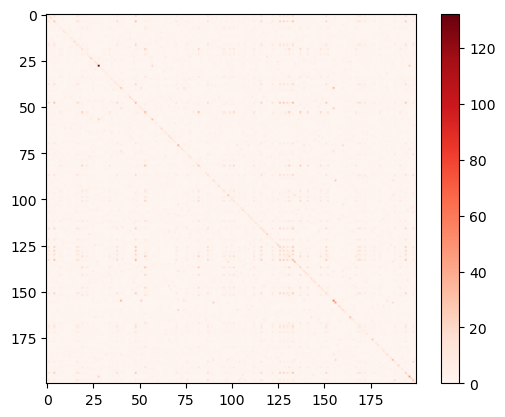

In [9]:
fig, axs = plt.subplots(nrows = 1, ncols = 1)

ax = axs
im = ax.imshow(counts.count_matrix, cmap = "Reds")
fig.colorbar(im, ax = ax)

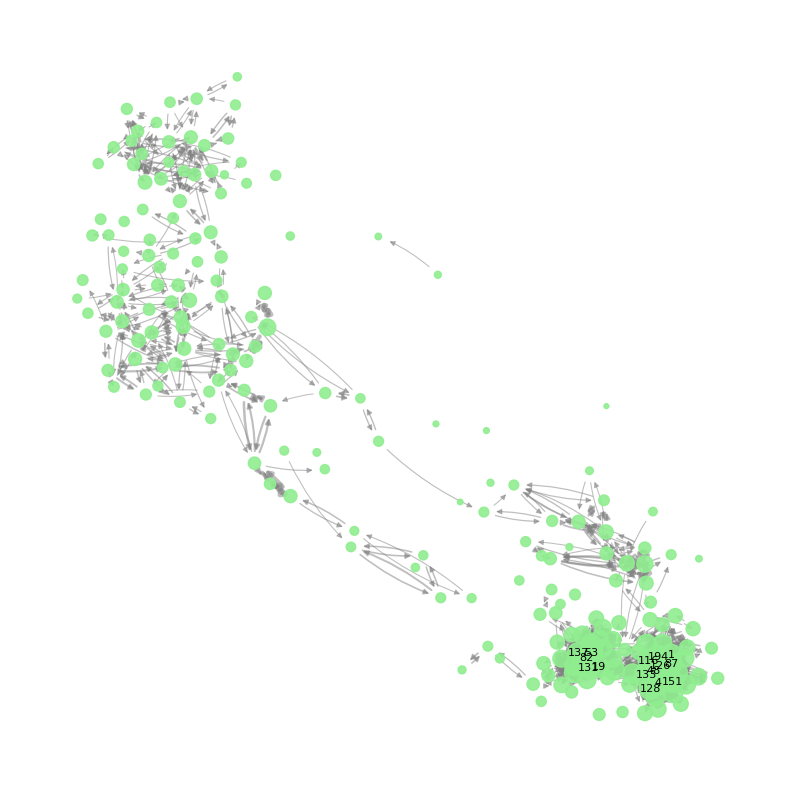

In [10]:
C = counts.count_matrix.copy()

# Full graph: used only for layout
G_full = nx.from_numpy_array(C, create_using=nx.DiGraph())

pos = nx.spring_layout(
    G_full,
    weight="weight",
    k=0.5,
    seed=0
)

# Sparse graph: used only for visualization
G_vis = nx.DiGraph()
G_vis.add_nodes_from(G_full.nodes())



threshold_counts = 4
for i in range(C.shape[0]):
    for j in range(C.shape[0]):
        if C[i, j] > threshold_counts and i != j:
            G_vis.add_edge(i, j, weight=C[i, j])

node_weights = C.sum(axis=0) + C.sum(axis=1)
node_sizes = 1000 * np.log10(1 + node_weights / node_weights.max())

edge_weights = np.array([d["weight"] for _, _, d in G_vis.edges(data=True)])
edge_widths = 0.2 + 5 * edge_weights / edge_weights.max()

plt.figure(figsize=(10, 10))

nx.draw_networkx_nodes(
    G_vis, pos,
    node_size=node_sizes,
    node_color="lightgreen",
    alpha=0.9
)

nx.draw_networkx_edges(
    G_vis, pos,
    width=edge_widths,
    edge_color="gray",
    alpha=0.5,
    arrows=True,
    arrowsize=8,
    connectionstyle="arc3,rad=0.1"
)

largest = np.argsort(node_weights)[-15:]
labels = {i: str(i) for i in largest}

nx.draw_networkx_labels(
    G_vis, pos,
    labels=labels,
    font_size=8
)

plt.axis("off")
plt.show()

**Comment** nice that the graph with force directedc layout looks almost bipartite. Perhaps the two hubs are the folded and unfolded basins? Still too early to say, but encouraging to see.

#### Select largest connected component

A graph induced by the adjacency matrix is called strongly connected if the edges are directed and there is a path from each state i to each state j. It is called weakly connected if the edges are undirected and there is a path from each state 
i to each state j.

We need to identify the **largest strongly connected component** of the graph.

In [11]:
print("Weakly connected sets:", len(counts.connected_sets(directed=False)))
print("Strongly connected sets:", len(counts.connected_sets(directed=True)))

Weakly connected sets: 1
Strongly connected sets: 1


In this case, the graph is already strongly connected: good.

### Estimate the transition matrix  $\quad T_\tau$

Possibilities:

- Maximum Likelihood Estimator or Bayesian
    - if bayesian, which prior
- Detailed balance constraint: yes or no

In [12]:
estimator = MaximumLikelihoodMSM(
    reversible=True,
    stationary_distribution_constraint=None
)

Lag this model was estimated at:  50


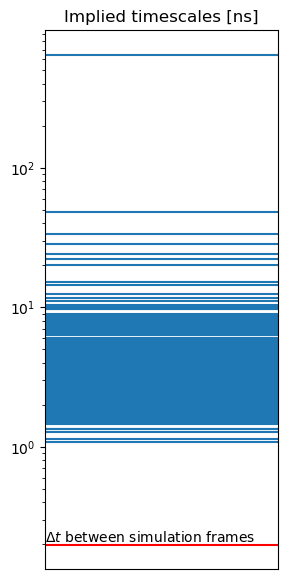

In [13]:
msm = estimator.fit(counts).fetch_model() # instance of class MarkovStateModelCollection
print("Lag this model was estimated at: ", msm.lagtime) # inherited it from the count matrix model, nice!

timescales_ns = msm.timescales()*time_between_frames_mus * 10**3


#################################################################
fig, ax = plt.subplots(figsize = (3, 7))

for time in timescales_ns:
    ax.axhline(time)
ax.set_xticks([])

ax.axhline(time_between_frames_mus * 10**3, color = "red")
ax.text( x = 0, y = time_between_frames_mus * 10**3 + 0.01, s = r"$\Delta t$ between simulation frames")

ax.set_yscale("log", base = 10)
ax.set_title("Implied timescales [ns]")
plt.show()

### Free energy surface from the markov model, projected along the first PCA components

---
## Validation

1. Implied timescales convergence test
2. autocorrelation test

### Implied timescales convergence test

In [14]:
lag_frames_array = np.logspace(1, 3) # [frames] , base 10

all_timescales = []
for lag in lag_frames_array:
    # compute count matrix
    estimator_counts = TransitionCountEstimator(
        lagtime=int(lag),
        count_mode="sliding-effective"
    )
    counts = estimator_counts.fit(traj).fetch_model()
    # estimate transition matrix
    estimator_transition = MaximumLikelihoodMSM(
        reversible=True,
        stationary_distribution_constraint=None
    )
    msm_temporary = estimator_transition.fit(counts).fetch_model()
    all_timescales.append(msm_temporary.timescales())
all_timescales = np.array(all_timescales)

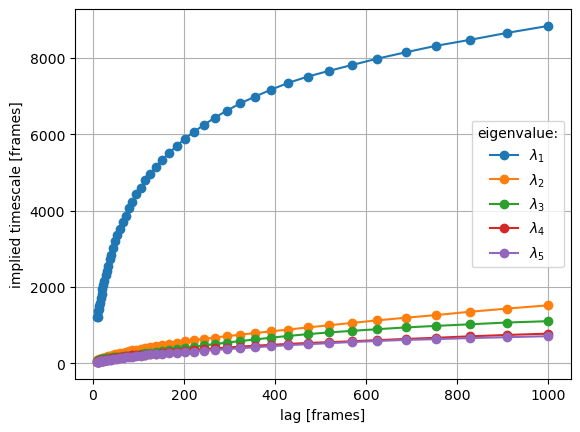

In [15]:
fig, ax = plt.subplots()

for eig_idx in range(5):
    ax.plot(lag_frames_array, all_timescales[:, eig_idx], marker = "o", label = rf"$\lambda_{eig_idx + 1}$")

ax.set_xlabel("lag [frames]")
ax.set_ylabel("implied timescale [frames]")
ax.legend(title = "eigenvalue:")
ax.grid()

**Comment** convergence is not perfect. Can we consider it *reasonably* good? 

For the moment, I do and I proceed further in the analysis.

In [16]:
__lag__= 200 # from the implied timescales convergence test



estimator_counts = TransitionCountEstimator(
    lagtime=int(__lag__),
    count_mode="sliding-effective"
)
counts = estimator_counts.fit(traj).fetch_model()
# estimate transition matrix
estimator_transition = MaximumLikelihoodMSM(
    reversible=True,
    stationary_distribution_constraint=None
)
msm = estimator_transition.fit(counts).fetch_model()

---
### Autocorrelation test (RMSD)

Lets call $\theta (\vec{x})$ an observable of the molecular trajectory.
- Construct the vector of observables $\mathbf{\theta} = (\theta_1, \, \theta_N)$ containing the value of the observable $\theta$ in each markov microstate.


    0. For each cluster center, I take the state closest to the cluster center as the representative state of the markov microstate;
    1. For each representative state, extract its temporal frame index and use it to retrieve the corresponding value of the RMSD from the crystal structure.

- Compute the model predicted autocorrelation according to:

$$
ACF_\theta(k) = \frac{\sum_{i=1}^{N}\, \lambda_i^k\, \langle\mathbf{\theta}, \mathbf{r_i} \rangle^2}{\sum_{i=1}^{N}\, \langle\mathbf{\theta}, \mathbf{r_i}\rangle^2}
$$

where the $\mathbf{r}_i$ are the right eigenvectors of the transition matrix.

- Compare with the empirical autocorrelation.

In [17]:
pca_traj = np.load("intermediate_outputs/mindists2_pca_5.npz")["arr_0"]
pca_traj.shape

(1526041, 5)

In [18]:
from tqdm.auto import tqdm
from numpy.linalg import norm

n_microstates = centers.shape[0]
representative_frames = np.zeros(centers.shape[0])

representative_frames = np.array([
    np.argmin(norm(pca_traj - center, axis=1))
    for center in tqdm(centers, desc="Finding representative frames")
])

Finding representative frames:   0%|          | 0/200 [00:00<?, ?it/s]

In [19]:
RMSD_timeseries = np.load("intermediate_outputs/RMSD_crystal_nm.npy")
theta_array = RMSD_timeseries[representative_frames]

In [20]:
from scipy.signal import correlate
from deeptime.markov.tools.analysis import correlation



def get_empirical_autocorrelation(obs):
    obs = obs - obs.mean()
    acf = correlate(obs, obs, mode="full")
    acf = acf[acf.size // 2:]      # keep non-negative lags
    acf /= acf[0]                  # normalize so acf[0] = 1
    return acf


def get_msm_autocorrelation(obs, msm, times_array):
    """
    obs: array of observables, one for each microstate
    msm: object of the class deeptime::MarkovStateModelCollection
    """
    # center the observable using the stationary distribution
    obs_mean = np.dot(msm.stationary_distribution, obs)
    obs = obs - obs_mean
    variance = correlation(T = msm.transition_matrix, 
                                obs1 = obs, 
                                obs2=None, 
                                times=(0,), 
                                k=None, 
                                ncv=None)[0]
    
    times_array_in_units_of_tau = np.array(times_array / msm.lagtime, dtype = int)
    acf = correlation(T = msm.transition_matrix, 
                                obs1 = obs, 
                                obs2=None, 
                                times=times_array_in_units_of_tau, 
                                k=None, 
                                ncv=None)
    
    return acf/variance

In [21]:
empirical_acf = get_empirical_autocorrelation(RMSD_timeseries)
model_acf = get_msm_autocorrelation(theta_array, msm, times_array=np.arange(0, 100000))

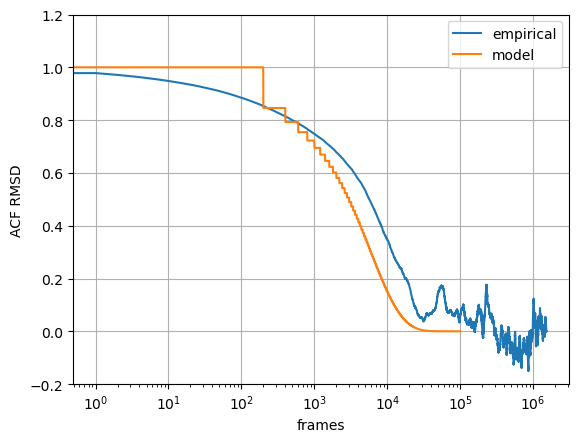

In [22]:
fig, ax = plt.subplots()


ax.plot(np.arange(len(empirical_acf)), empirical_acf, label = "empirical")
ax.plot(np.arange(len(model_acf)), model_acf, label = "model")
ax.legend()
ax.set_xscale("log", base = 10)
ax.set_ylabel("ACF RMSD")
ax.set_xlabel("frames")
ax.grid()
plt.ylim(-0.2, 1.2)
plt.show()

Seems quite good, but without error bars what can you say?

TODO:
- look into Bayesian MSMs
- optionally consider bootstrapping.

---
## Coarse-graining and validation of the *macrostate* model


[From book, ch 2.5] 
There are a number of advantages to coarse-graining microstate models by merging rapidly mixing microstates into larger macrostates. 

- First of all, one can sometimes build mesoscale models that are just as quantitatively predictive as the original microstate model but are far more compact. 

- Secondly, one can build models with few enough states that they are comprehensible and can be used to **gain an intuition** for a system and generate hypotheses, though they may no longer be quantitatively predictive.


Two major questions have to be addressed to build these coarse-grained models. 

- First, how should one determine which microstates to merge together? 
- Secondly, how many macrostates should one build?

These questions are closely related.


**Choice of the algorithm**

- The standard approach is PCCA+. PCCA (without the +) is excellently explained in the book. 
- authors of HP35 references suggest instead:
    - Starting with the above-defined microstates, MPP first calculates the transition matrix of these states, using a lag time τMPP = 10 ns. (The choice of τMPP is explained in the discussion of Figure 7a below.)
    -  If the self- transition probability of a given state is lower than a certain metastability criterion Qmin ∈ (0, 1), the state will be lumped with the state to which the transition probability is the highest. 
    - This procedure is reiterated, until there are no more transitions for a given Qmin."


Let's start from PCCA+.

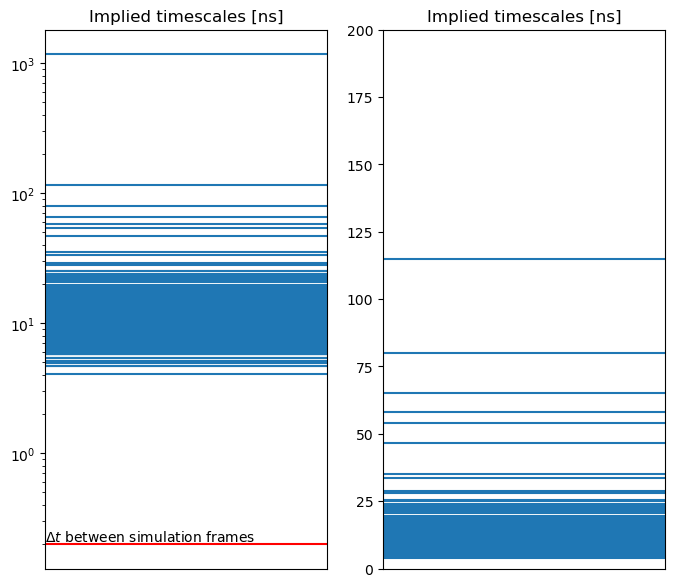

In [23]:
timescales_ns = msm.timescales() * time_between_frames_mus * 10**3


#################################################################
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (8, 7))

for ax in axs:

    for time in timescales_ns:
        ax.axhline(time)
    ax.set_xticks([])
    ax.set_title("Implied timescales [ns]")


axs[0].axhline(time_between_frames_mus * 10**3, color = "red")
axs[0].text( x = 0, y = time_between_frames_mus * 10**3 + 0.01, s = r"$\Delta t$ between simulation frames")
axs[0].set_yscale("log", base = 10)




axs[1].set_ylim(0, 200)
plt.show()

In [24]:
from deeptime.markov.tools.analysis import pcca_memberships


def PCCA_assign_microstates(T, n_macro, threshold = 0.):
    """
    Compute nmacro macrostates with PCCA++.
    Assign microstate to the PCCA++ macrostate with highest probability - if there
    exists one of such states with probability > threshold.
    Else, mark as "transition point": index -1
    """
    membership_probs = pcca_memberships(T = T, m = n_macro)

    idxs = np.argmax(membership_probs, axis = 1)
    max_probs = np.max(membership_probs, axis = 1)
    idxs = np.where(max_probs > threshold, idxs, -1)
    return idxs


n_macro = 6
threshold = 0. # cannot choose a threshold higher because i dont want to have unassigned microstates, which would be a problem for MSM construction
micro_assignments = PCCA_assign_microstates(T = msm.transition_matrix, n_macro = n_macro, threshold = threshold)
traj_pcca_assignments = np.array([micro_assignments[microstate] for microstate in traj])
np.unique(traj_pcca_assignments)

array([0, 1, 2, 3, 4, 5])

#### Save to file 
the trajectory further discretized into macrostates

In [25]:
# Save to file
np.save(f"intermediate_outputs/traj_pcca_{n_macro}_assignments.npy", traj_pcca_assignments)

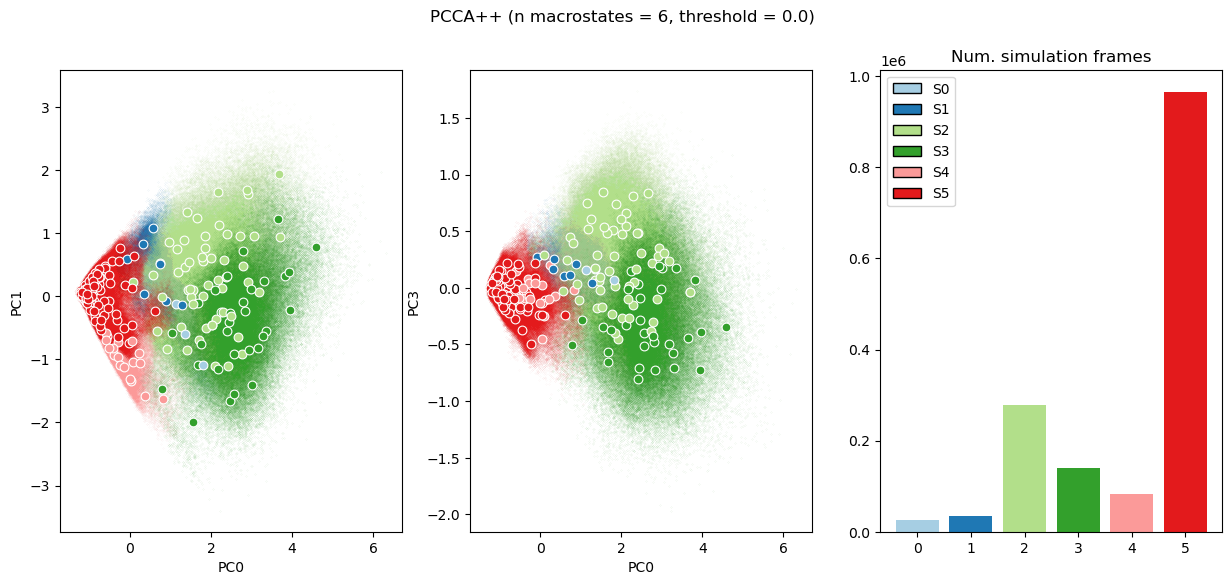

In [26]:
from matplotlib.patches import Patch
from matplotlib import color_sequences
color_sequence = color_sequences['Paired']

colors = ["grey"] + color_sequence

def assign_color(idx, color_sequence):
    return color_sequence[idx]

micro_colors = [assign_color(idx, color_sequence) for idx in micro_assignments]

################################

fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(15, 6))

axs = axs.flatten()
for ax_id, (pca_x, pca_y) in enumerate([(0, 1), (0, 3)]):
    ax = axs[ax_id]
    for i, center in enumerate(centers):
        ax.scatter(center[pca_x], center[pca_y], 
                    marker = "o", 
                    s=40,
                    facecolor = micro_colors[i],
                    edgecolor = "white",
                    linewidth=0.8,
                    zorder=10)

    for id in range(-1, n_macro):
        frames = pca_traj[traj_pcca_assignments == id]
        ax.scatter(
            frames[:, pca_x],
            frames[:, pca_y],
            color=assign_color(id, color_sequence),
            alpha = 0.3,
            s=0.01,
        )
    ax.set_xlabel(f"PC{pca_x}")
    ax.set_ylabel(f"PC{pca_y}")
    #ax.set_title("PCA projection")


ax = axs[2]
bins, counts = np.unique(traj_pcca_assignments, return_counts = True)
ax.bar(bins, counts, color = [assign_color(bin + 1, colors) for bin in bins] )

# custom legend handles
handles = []
for b in bins:
    if b == -1:
        color = colors[0] 
        label = "Unassigned" 
    else:
        label = f"S{b}"
        color = colors[b+1]
    handles.append(
        Patch(facecolor=color, edgecolor="black", label=label)
    )
ax.set_title("Num. simulation frames")
ax.legend(handles=handles)


plt.suptitle(f"PCCA++ (n macrostates = {n_macro}, threshold = {threshold})")
plt.show()

### Validation of the macrostate model: Chapman-Kolmogorov (= relaxation) test

**Question** how to justify the choice of the number of macrostates? 

from the book, ch 6.4.4:


"
We employed a definition of 50 sets that separate the most slowly convert- ing (“metastable”) parts of state space. *The number of sets can be chosen by fixing a timescale of interest (here 100 ns), then the number of metastable sets are given by the number of implied timescales of the transition matrix slower than that timescale of interest*. The definition of metastable states was obtained by PCCA+.
"



One possibility is build macrostate MSMs at varying number of macrostates and score them with CK test, choosing the model that has better behaviour in the CK test. Also, we can enforce a minimum metastability threshold, to ensure that the macrostates correspond to *metastable* states.



For the moment, I just build macrostate MSM and implement the CK, then I will perform comparative CK.


### Build macrostate MSM

[0 1 2 3 4 5]
(1526041,)


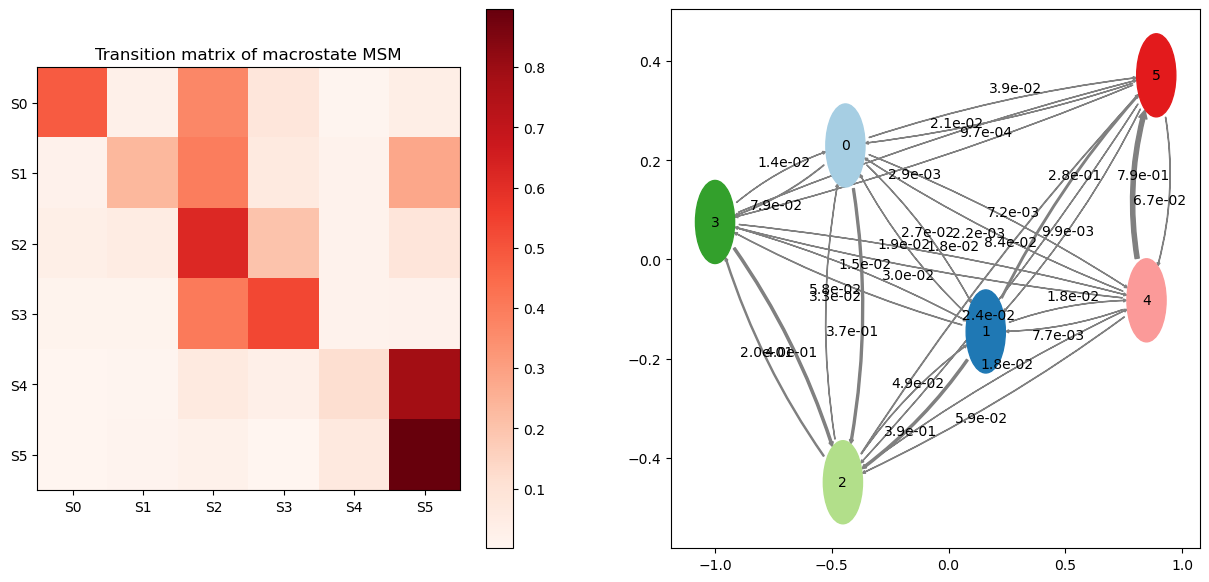

In [27]:
from deeptime.util.validation import ck_test
from deeptime.plots import plot_ck_test, Network
from tqdm.auto import tqdm



__lag__ = 1000 # should be the same as the one of the microstate MSM?

## First: build a macrostate MSM from the macrostate trajectory
print(np.unique(traj_pcca_assignments))
print(traj_pcca_assignments.shape)

estimator_counts = TransitionCountEstimator(
    lagtime=int(__lag__),
    count_mode="sliding-effective"
)

macro_counts = estimator_counts.fit(traj_pcca_assignments).fetch_model()
# estimate transition matrix
estimator_transition = MaximumLikelihoodMSM(
    reversible=True,
    stationary_distribution_constraint=None
)
macro_msm = estimator_transition.fit(macro_counts).fetch_model()



fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (15, 7))



im = axs[0].imshow(macro_msm.transition_matrix, cmap = "Reds")
fig.colorbar(im, ax = axs[0])
axs[0].set_xticks(np.arange(0, n_macro , 1))
axs[0].set_yticks(np.arange(0, n_macro , 1))
axs[0].set_xticklabels([f"S{i}" for i in range(n_macro)])
axs[0].set_yticklabels([f"S{i}" for i in range(n_macro)])
axs[0].set_title("Transition matrix of macrostate MSM")



G = nx.from_numpy_array(macro_msm.transition_matrix, create_using=nx.DiGraph())
pos = nx.spring_layout(
    G,
    weight="weight",
    k=0.5,
    seed=0
)

nx = Network(
   adjacency_matrix=macro_msm.transition_matrix, 
   state_colors = colors[1:n_macro+1],
   pos = pos
)
nx.plot(ax = axs[1])
plt.show()

### Perform CK test

In [28]:
from deeptime.util.validation import ck_test


def estimate_macro_msm(macro_dtrajs, lag):
    estimator = MaximumLikelihoodMSM(
        lagtime=lag,
        reversible=False,
        allow_disconnected=True
    )
    return estimator.fit(macro_dtrajs).fetch_model()


class TransitionMatrixObservable:
    def __call__(self, model, mlag=1):
        if model is None:
            n = self.n_states
            return np.eye(n)

        T = np.asarray(model.transition_matrix)

        if mlag == 0:
            return np.eye(T.shape[0])

        if not float(mlag).is_integer():
            raise ValueError("mlag must be integer for MSM transition matrices.")

        return np.linalg.matrix_power(T, int(mlag))


# Your macrostate trajectory
# shape: (n_frames,), entries are macrostate labels 0, 1, ..., M-1
macro_dtraj = traj_pcca_assignments
macro_dtrajs = [macro_dtraj]

tau = 1000
multiples = np.arange(1, 100)

models = [
    estimate_macro_msm(macro_dtrajs, lag=tau * k)
    for k in multiples
]

observable = TransitionMatrixObservable()
observable.n_states = n_macro

ck = ck_test(
    models=models,
    observable=observable,
    test_model=models[0],
    err_est = True,
    include_lag0=True
)

[    0  1000  2000  3000  4000  5000  6000  7000  8000  9000 10000 11000
 12000 13000 14000 15000 16000 17000 18000 19000 20000 21000 22000 23000
 24000 25000 26000 27000 28000 29000 30000 31000 32000 33000 34000 35000
 36000 37000 38000 39000 40000 41000 42000 43000 44000 45000 46000 47000
 48000 49000 50000 51000 52000 53000 54000 55000 56000 57000 58000 59000
 60000 61000 62000 63000 64000 65000 66000 67000 68000 69000 70000 71000
 72000 73000 74000 75000 76000 77000 78000 79000 80000 81000 82000 83000
 84000 85000 86000 87000 88000 89000 90000 91000 92000 93000 94000 95000
 96000 97000 98000 99000]
(100, 6, 6)
(100, 6, 6)


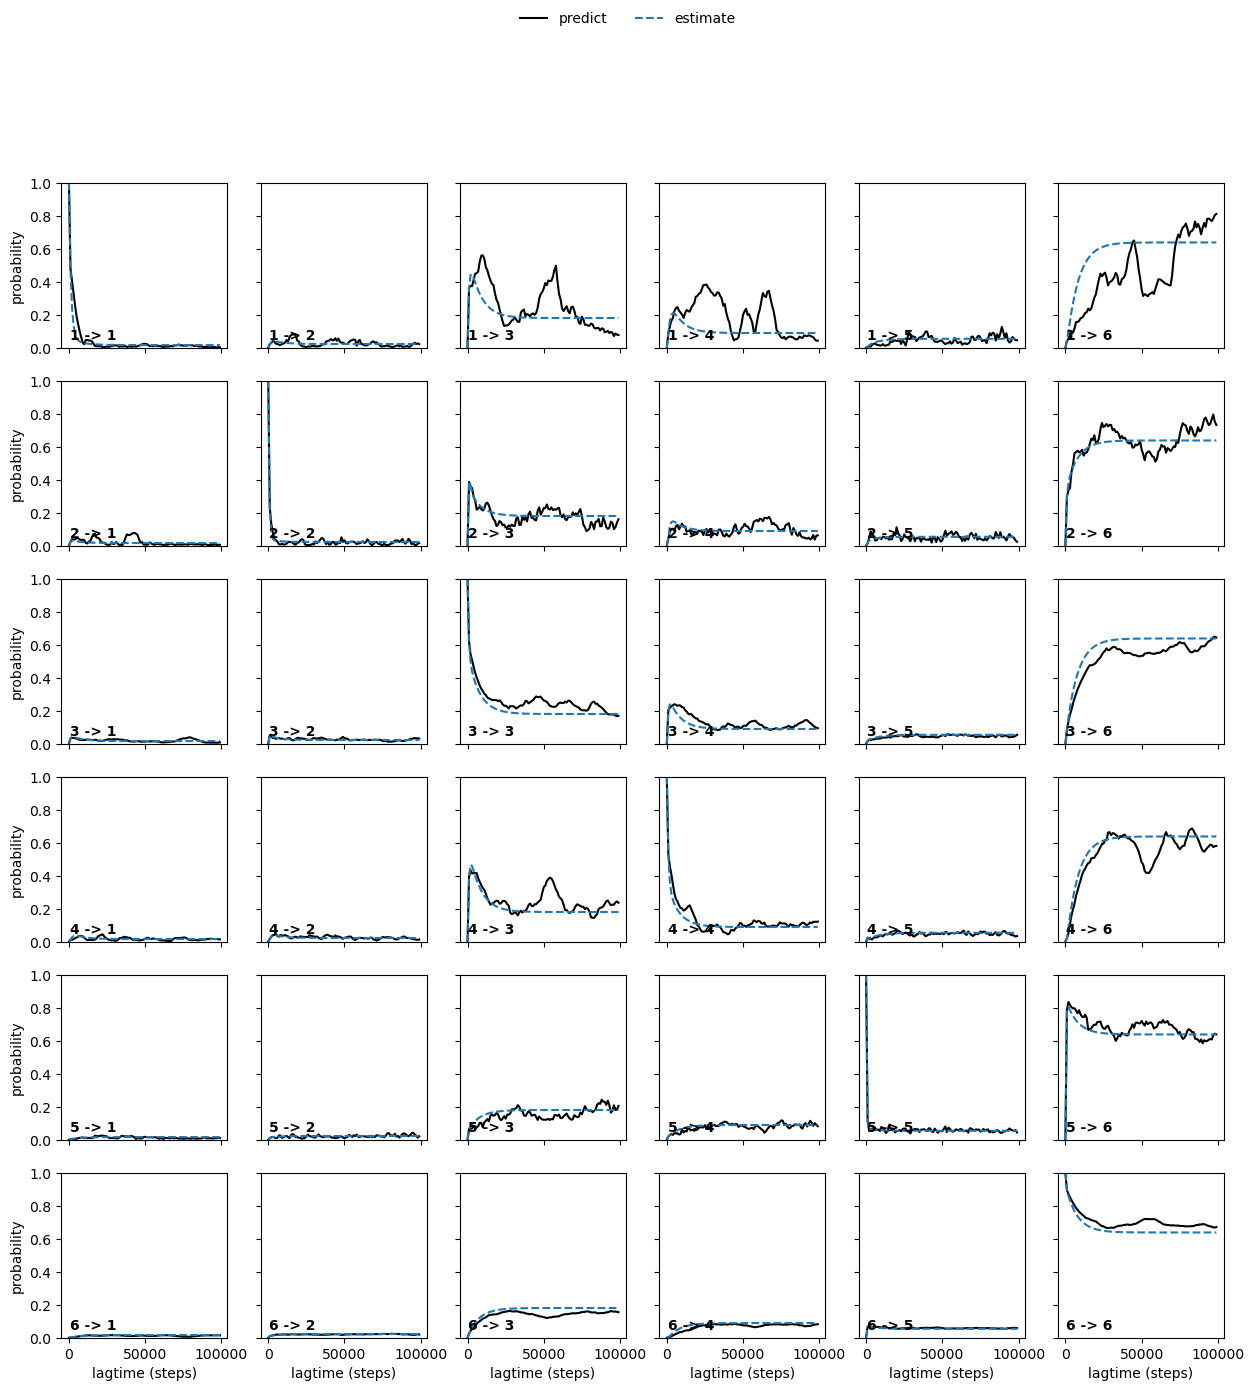

In [29]:
ck.plot()
print(ck.lagtimes)
print(ck.predictions.shape)
print(ck.estimates.shape)

For each row $i$ (starting macrostate) and every lag multiple $k$, compute:

$$
e_i(k) := \sum_{j=1}^{N} | T^{est.}(k \,\tau)_{i,j} - T^{pred.}(k \,\tau)_{i,j} | 
$$


$$
e_i(k) := \sum_{j=1}^{N} | T(k \,\tau)_{i,j} - [T(\tau)]^{k}_{i,j} |
$$


The quantity $e_i(k)$ is **bound** in the range $[0,2]$: 

- it is zero when the two probability distributions are identical
- it is $2$ when they have disjoint support (e.g. one is 1 in a state and one is 1 in a different state, or more complex situations).

This makes it a good quantity for evaluating the CK test.

In [30]:
def evaluate_ck_test(ck):
    #print("Lagtimes:", ck.lagtimes)
    #print("Predictions shape:", ck.predictions.shape)
    #print("Estimates shape:", ck.estimates.shape)

    n_lags = len(ck.lagtimes)
    n_states = ck.predictions.shape[1]

    E = np.zeros((n_lags, n_states))

    for k in range(n_lags):
        
        pred = ck.predictions[k] 
        est = ck.estimates[k]

        for i in range(n_states):
            # row stochastic matrices: columns contain destination states
            # pred[i] and est[i] refer to i as the source state and contain the probabilities of transitioning to each destination state
            E[k, i] = np.sum(np.abs(pred[i] - est[i]))

    # average over source states
    median_l1 = np.median(E, axis=1) 
    p90_l1 = np.percentile(E, 90, axis=1)

    return {
        "e": E,                       # shape (n_lags, n_states)
        "median_l1": median_l1,       # shape (n_lags,)
        "std": np.std(E, axis=1),       # shape (n_lags,)
        "p90_l1": p90_l1,             # shape (n_lags,)
    }   


evaluation_results = evaluate_ck_test(ck)   

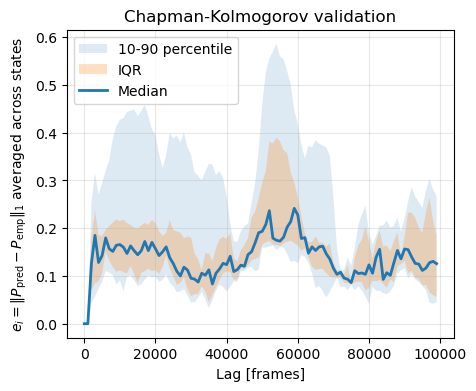

In [31]:
fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(5, 4)
)


E = evaluation_results["e"]

# Quantile bands
q10 = np.percentile(E, 10, axis=1)
q25 = np.percentile(E, 25, axis=1) # IQR interquartile range (25-75)
q75 = np.percentile(E, 75, axis=1)
q90 = np.percentile(E, 90, axis=1)

ax.fill_between(
    ck.lagtimes,
    q10,
    q90,
    alpha=0.15,
    label="10-90 percentile"
)

ax.fill_between(
    ck.lagtimes,
    q25,
    q75,
    alpha=0.25,
    label="IQR"
)

# Summary curves
ax.plot(
    ck.lagtimes,
    evaluation_results["median_l1"],
    lw=2,
    label="Median"
)

ax.set_xlabel("Lag [frames]")
ax.set_ylabel(r"$e_i=\|P_{\rm pred}-P_{\rm emp}\|_1$ averaged across states")
ax.set_title("Chapman-Kolmogorov validation")
ax.grid(alpha=0.3)
ax.legend()
plt.show()

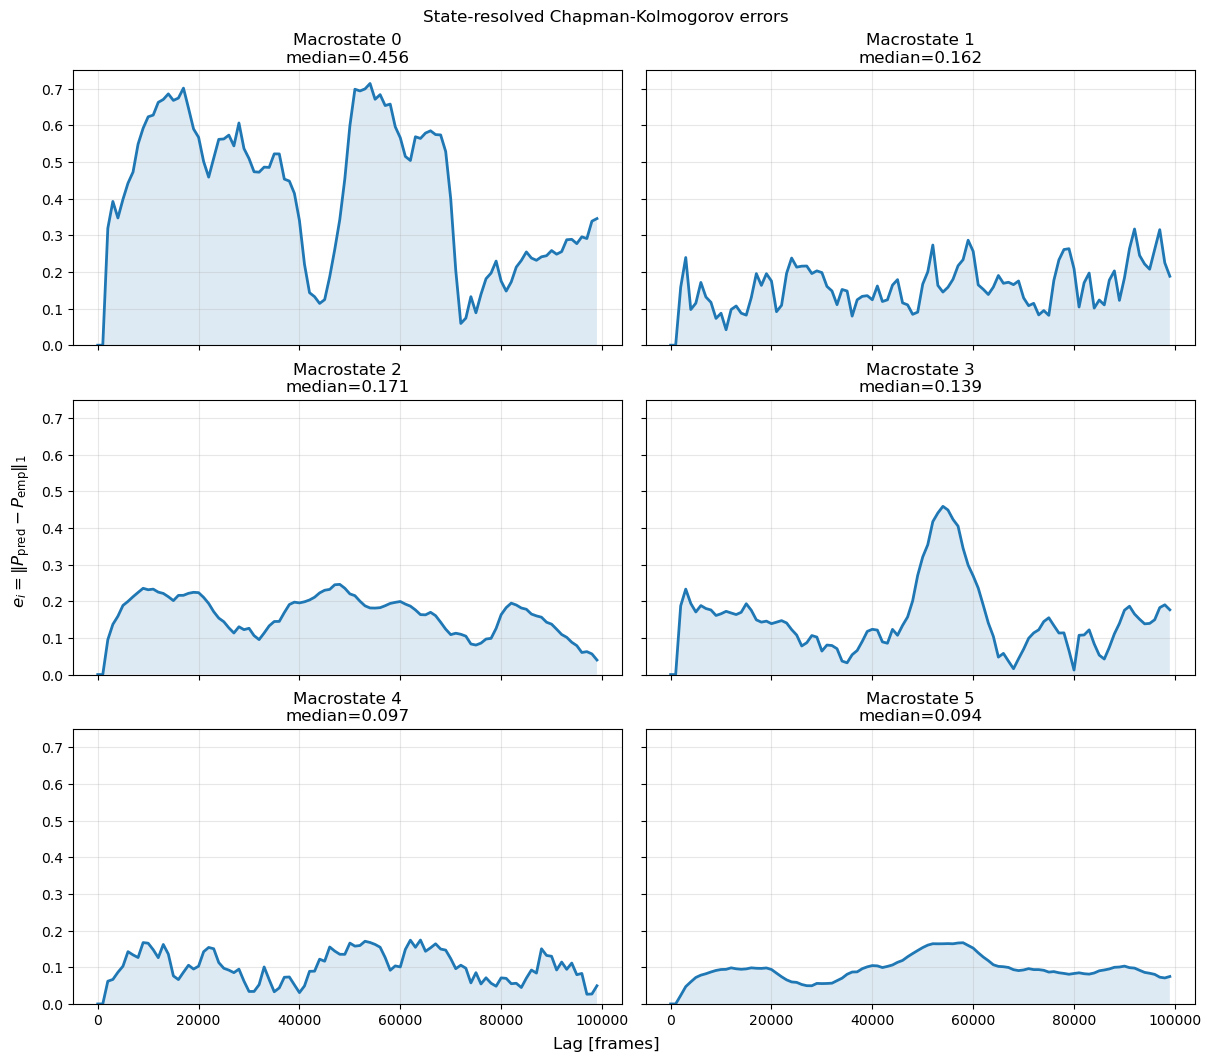

In [32]:
import math

E = evaluation_results["e"]   # (n_lags, n_states)
lags = np.asarray(ck.lagtimes)

n_states = E.shape[1]

ncols = 2
nrows = math.ceil(n_states / ncols)

fig, axs = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(6*ncols, 3.5*nrows),
    sharex=True,
    sharey=True,
    constrained_layout=True
)

axs = np.atleast_1d(axs).ravel()

for i in range(n_states):
    ax = axs[i]

    ax.plot(
        lags,
        E[:, i],
        #marker="o",
        lw=2
    )

    ax.fill_between(
        lags,
        0,
        E[:, i],
        alpha=0.15
    )

    ax.set_title(
        f"Macrostate {i}\n"
        f"median={np.median(E[:, i]):.3f}"
    )

    ax.grid(alpha=0.3)
    ax.set_ylim(bottom=0)

for ax in axs[n_states:]:
    ax.axis("off")

fig.supxlabel("Lag [frames]")
fig.supylabel(r"$e_i=\|P_{\rm pred}-P_{\rm emp}\|_1$")
fig.suptitle("State-resolved Chapman-Kolmogorov errors")

plt.show()

#### macrostate-MSM lagtime selection through CK test validation.